In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 73.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

In [3]:
df = pd.read_csv("df_final_final.csv")

print(df.shape)
df.head()

(5037, 15)


,name,title,context,date,year,full_text,cleaned_tokens,text_length,token_count,cleaned_tokens_no_name,token_count_no_name,cleaned_tokens_final,token_count_final,cleaned_tokens_analysis,token_count_analysis
0,메모러블모먼트,"둔촌동역카페 메모러블모먼트 메뉴 추천, 강동구 블루리본카페 올림픽공원카페 후기",메모러블모먼트 ✔️서울 강동구 양재대로 83길 14 ✔️5호선 둔촌동역 3번 출구에...,2주 전,2026,"둔촌동역카페 메모러블모먼트 메뉴 추천, 강동구 블루리본카페 올림픽공원카페 후기 메모...",둔촌동역 메모 러블 모먼트 메뉴 블루리본 올림픽 공원 메모 러블 모먼트 양재대로 호...,262,36,둔촌동역 메뉴 블루리본 올림픽 공원 양재대로 호선 둔촌동역 출구 영업 시간 블루리본...,27,둔촌동역 메뉴 블루리본 올림픽 공원 양재대로 둔촌동역 출구 블루리본 맛집 주차 공간...,23,메뉴 블루리본 블루리본 공간 협소 한살림 유료 도보 블루리본 우연히,10
1,메모러블모먼트,강동구 분위기 좋은 카페 메모러블모먼트 블루리본 디저트 솔직 후기,특히 아몬드가 인상적이어서 디저트 메뉴를 함께 즐기기 좋은 곳이었다. 분위기도 조용...,2026.03.22.,2026,강동구 분위기 좋은 카페 메모러블모먼트 블루리본 디저트 솔직 후기 특히 아몬드가 인...,분위기 좋다 메모 러블 모먼트 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 함께 ...,198,32,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 함께 좋다 분위기 조용하...,26,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 좋다 분위기 조용하다 깔...,25,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 좋다 분위기 조용하다 깔...,24
2,메모러블모먼트,올림픽공원 근처 둔촌동 카페 메모러블모먼트 Memorable Moment 후기,내돈내산 둔촌동 카페 메모러블 모먼트 방문 후기. 메모러블 모먼트라는 카페에 다녀왔...,2026.07.10.,2026,올림픽공원 근처 둔촌동 카페 메모러블모먼트 Memorable Moment 후기 내돈...,올림픽 공원 근처 메모 러블 모먼트 메모 러블 모먼트 메모 러블 모먼트 골목 국민 ...,241,38,올림픽 공원 근처 골목 국민 떡볶이 같다 건물 주차장 따로 없다 올림픽 공원 가깝다...,26,올림픽 공원 골목 국민 떡볶이 건물 주차장 따로 올림픽 공원 가깝다 저희 올림픽 공...,20,국민 떡볶이 따로 가깝다 저희 산책 프랜차이즈 손님 생각,9
3,메모러블모먼트,[둔촌동 카페]메모러블모먼트 | 블루리본 받은 분위기 좋은 카페,메모러블모먼트 서울 강동구 성내동 440-25 월-금 8:30-23:00 토일 8:...,2026.08.01.,2026,[둔촌동 카페]메모러블모먼트 | 블루리본 받은 분위기 좋은 카페 메모러블모먼트 서울...,메모 러블 모먼트 블루리본 분위기 좋다 메모 러블 모먼트 토일 라스트 마감 안녕하다...,252,35,블루리본 분위기 좋다 토일 라스트 마감 안녕하다 루시 이다 근처 우연히 발견 블루리...,29,블루리본 분위기 좋다 토일 라스트 마감 루시 우연히 발견 블루리본 메뉴 생각 다양하...,22,블루리본 분위기 좋다 토일 라스트 마감 루시 우연히 발견 블루리본 메뉴 생각 다양하...,22
4,메모러블모먼트,"[강동구 카페] 찰나의 순간이 기록되는 곳, 메모러블모먼트(Memorable Mom...",강동구에서 이미 감성 카페로 입소문이 자자한 '메모러블모먼트'입니다. 저는 참새가 ...,2026.04.11.,2026,"[강동구 카페] 찰나의 순간이 기록되는 곳, 메모러블모먼트(Memorable Mom...",찰나 순간 기록 메모 러블 모먼트 솔직 이미 감성 소문 자자하다 메모 러블 모먼트 ...,270,43,찰나 순간 기록 솔직 이미 감성 소문 자자하다 이다 참새 방앗간 근처 무조건 이다 ...,37,찰나 순간 기록 솔직 이미 감성 소문 자자하다 참새 방앗간 무조건 양재대로 강동역 ...,29,찰나 순간 기록 솔직 이미 감성 소문 자자하다 참새 방앗간 특징 블루리본 베이 연속...,24


In [ ]:
#추가 불용어 제거
df['cleaned_tokens_add'] = df['cleaned_tokens_analysis'].copy()
additional_stopwords = {
    '보스', '울트라', '헤드폰', '세대','체인', '블록',
    '바이', '샌드', '낸스', '수수료', '우연히','길동',
    '가입', '코인', '링크', '머신', '한살림', '잠실',
    '거래', '비트', '콘티','채스','터리','낸스'
}

In [ ]:
def remove_additional_stopwords(text):

    words = str(text).split()

    filtered_words = [
        word for word in words
        if word not in additional_stopwords
    ]

    return ' '.join(filtered_words)

In [ ]:
df['cleaned_tokens_add'] = (
    df['cleaned_tokens_analysis']
    .apply(remove_additional_stopwords)
)
df[
    ['cleaned_tokens_analysis', 'cleaned_tokens_add']
].head(30)

,cleaned_tokens_analysis,cleaned_tokens_add
0,메뉴 블루리본 블루리본 공간 협소 한살림 유료 도보 블루리본 우연히,메뉴 블루리본 블루리본 공간 협소 유료 도보 블루리본
1,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 좋다 분위기 조용하다 깔...,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 좋다 분위기 조용하다 깔...
2,국민 떡볶이 따로 가깝다 저희 산책 프랜차이즈 손님 생각,국민 떡볶이 따로 가깝다 저희 산책 프랜차이즈 손님 생각
3,블루리본 분위기 좋다 토일 라스트 마감 루시 우연히 발견 블루리본 메뉴 생각 다양하...,블루리본 분위기 좋다 토일 라스트 마감 루시 발견 블루리본 메뉴 생각 다양하다 커피...
4,찰나 순간 기록 솔직 이미 감성 소문 자자하다 참새 방앗간 특징 블루리본 베이 연속...,찰나 순간 기록 솔직 이미 감성 소문 자자하다 참새 방앗간 특징 블루리본 베이 연속...
5,인생 크림 라떼 맛있다 맛있다 크림 라떼 특별하다 여러분 인생 크림 라떼 크림 라떼...,인생 크림 라떼 맛있다 맛있다 크림 라떼 특별하다 여러분 인생 크림 라떼 크림 라떼...
6,블루리본 커피 한살림 유료 용상 분위기 좋다 아보 친구 가볍다 대화 좋다 공간,블루리본 커피 유료 용상 분위기 좋다 아보 친구 가볍다 대화 좋다 공간
7,크림 라떼 큰길 안쪽 아지트 도보 평일 주말 안내 도보 한살림 유료 최초 추가,크림 라떼 큰길 안쪽 아지트 도보 평일 주말 안내 도보 유료 최초 추가
8,아몬드 디저트 특별하다 라멘 식사 분위기 좋다 자연 외관 감각 느낌 한글 거의 보이...,아몬드 디저트 특별하다 라멘 식사 분위기 좋다 자연 외관 감각 느낌 한글 거의 보이...
9,산책 달달 디저트 도보 도보 산책 커피 취향 블루리본 무엇 궁금하다 의사 리뷰,산책 달달 디저트 도보 도보 산책 커피 취향 블루리본 무엇 궁금하다 의사 리뷰


In [ ]:
df[['name', 'cleaned_tokens_add']].head()

,name,cleaned_tokens_add
0,메모러블모먼트,메뉴 블루리본 블루리본 공간 협소 유료 도보 블루리본
1,메모러블모먼트,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 좋다 분위기 조용하다 깔...
2,메모러블모먼트,국민 떡볶이 따로 가깝다 저희 산책 프랜차이즈 손님 생각
3,메모러블모먼트,블루리본 분위기 좋다 토일 라스트 마감 루시 발견 블루리본 메뉴 생각 다양하다 커피...
4,메모러블모먼트,찰나 순간 기록 솔직 이미 감성 소문 자자하다 참새 방앗간 특징 블루리본 베이 연속...


In [ ]:
df.to_csv('df_final_final_add.csv', index=False, encoding='utf-8-sig')

In [ ]:
texts = (
    df['cleaned_tokens_add']
    .dropna()
    .astype(str)
    .apply(lambda x: x.split())
    .tolist()
)

In [ ]:
print(texts[:5])

[['메뉴', '블루리본', '블루리본', '공간', '협소', '유료', '도보', '블루리본'], ['분위기', '좋다', '블루리본', '디저트', '솔직', '아몬드', '인상', '디저트', '메뉴', '좋다', '분위기', '조용하다', '깔끔하다', '편하다', '괜찮다', '디저트', '레몬', '머랭', '케이크', '아몬드', '디저트', '블루리본', '분위기', '좋다'], ['국민', '떡볶이', '따로', '가깝다', '저희', '산책', '프랜차이즈', '손님', '생각'], ['블루리본', '분위기', '좋다', '토일', '라스트', '마감', '루시', '발견', '블루리본', '메뉴', '생각', '다양하다', '커피', '다양하다', '음료', '준비', '취향', '선택', '좋다', '디저트', '다양하다'], ['찰나', '순간', '기록', '솔직', '이미', '감성', '소문', '자자하다', '참새', '방앗간', '특징', '블루리본', '베이', '연속', '수록', '원두', '선택', '반려견', '동반', '오전', '오후', '주말', '감각', '공간']]


In [ ]:
texts = [text for text in texts if len(text) > 0]

print(f"최종 리뷰 수: {len(texts)}")

최종 리뷰 수: 5037


In [ ]:
#단어를 숫자
dictionary = corpora.Dictionary(texts)

print(f"전체 단어 수: {len(dictionary)}")

전체 단어 수: 13038


In [ ]:
corpus = [
    dictionary.doc2bow(text)
    for text in texts
]

In [ ]:
print(corpus[:3])

[[(0, 1), (1, 1), (2, 1), (3, 3), (4, 1), (5, 1)], [(2, 1), (3, 2), (6, 1), (7, 1), (8, 4), (9, 1), (10, 1), (11, 3), (12, 1), (13, 2), (14, 1), (15, 1), (16, 3), (17, 1), (18, 1)], [(19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1)]]


In [ ]:
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5, #최적토픽수 찾기
    random_state=42,
    passes=10,
    iterations=100,
    alpha='auto',
    eta='auto'
)

In [ ]:
topics = lda_model.print_topics(
    num_words=10
)

for topic in topics:
    print(topic)
    print()

(0, '0.024*"커피" + 0.022*"에그타르트" + 0.016*"원두" + 0.013*"맛있다" + 0.009*"라떼" + 0.009*"젤라또" + 0.008*"좋다" + 0.008*"두쫀쿠" + 0.007*"로스팅" + 0.007*"두바이"')

(1, '0.009*"음식점" + 0.007*"케이크" + 0.006*"예약" + 0.006*"트리" + 0.005*"플레" + 0.005*"베이글" + 0.004*"달인" + 0.004*"크리스마스" + 0.004*"식당" + 0.004*"동반"')

(2, '0.019*"할인" + 0.006*"청소" + 0.005*"사용" + 0.005*"코드" + 0.005*"엑스" + 0.005*"클릭" + 0.004*"작업" + 0.004*"거래소" + 0.004*"토큰" + 0.004*"선물"')

(3, '0.037*"좋다" + 0.030*"디저트" + 0.023*"분위기" + 0.022*"브런치" + 0.015*"감성" + 0.015*"맛있다" + 0.013*"커피" + 0.013*"데이트" + 0.010*"주말" + 0.009*"메뉴"')

(4, '0.045*"베이커리" + 0.034*"빵집" + 0.022*"바게트" + 0.012*"샌드위치" + 0.012*"맛있다" + 0.009*"케이크" + 0.009*"블루리본" + 0.008*"천호동" + 0.008*"호주" + 0.007*"베이글"')



In [ ]:
#0:커피/음료
#1:공간
#2:가격
#3:분위기
#4:빵

In [ ]:
#제외
topic_range = range(2, 11)

coherence_scores = []
models = []

for num_topics in topic_range:

    print(f"Topic {num_topics}개 학습 중...")

    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        iterations=100,
        alpha='auto',
        eta='auto'
    )

    coherence_model = CoherenceModel(
        model=model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence_score = coherence_model.get_coherence()

    models.append(model)
    coherence_scores.append(coherence_score)

    print(
        f"Topic {num_topics}: "
        f"Coherence Score = {coherence_score:.4f}"
    )

Topic 2개 학습 중...


KeyboardInterrupt: 

In [ ]:
#제외
coherence_df = pd.DataFrame({
    'num_topics': list(topic_range),
    'coherence_score': coherence_scores
})

coherence_df

,num_topics,coherence_score
0,2,0.311878
1,3,0.331658
2,4,0.415533
3,5,0.420653
4,6,0.414540
5,7,0.504371
6,8,0.506508
7,9,0.469594
8,10,0.479192


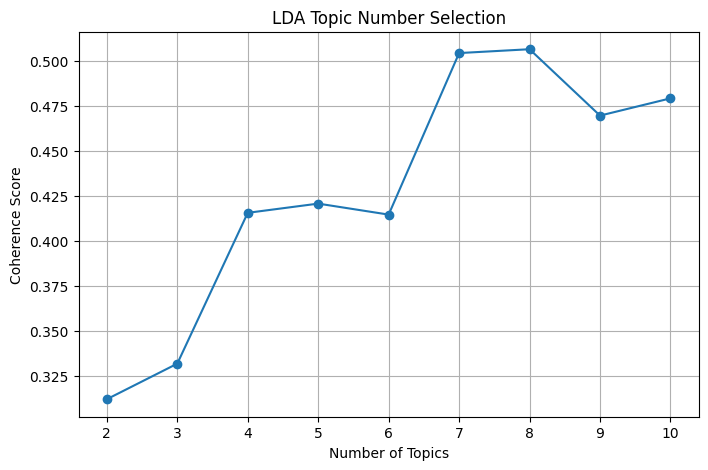

In [ ]:
#제외
#****토픽수 5로 결정함****
plt.figure(figsize=(8, 5))

plt.plot(
    coherence_df['num_topics'],
    coherence_df['coherence_score'],
    marker='o'
)

plt.xticks(list(topic_range))

plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score')

plt.title('LDA Topic Number Selection')

plt.grid(True)

plt.show()

In [ ]:
#제외
final_topics = final_lda_model.show_topics(
    num_topics=5,
    num_words=15,
    formatted=False
)

for topic_num, words in final_topics:

    print(f"\n{'=' * 50}")
    print(f"Topic {topic_num}")
    print('=' * 50)

    for word, weight in words:
        print(f"{word:<15} {weight:.4f}")


Topic 0
베이커리            0.0214
커피              0.0193
맛있다             0.0173
에그타르트           0.0163
빵집              0.0161
원두              0.0103
바게트             0.0103
블루리본            0.0102
라떼              0.0095
디저트             0.0084
좋다              0.0076
메뉴              0.0070
샌드위치            0.0054
두쫀쿠             0.0053
소금              0.0053

Topic 1
음식점             0.0077
예약              0.0047
식당              0.0045
플레              0.0043
케이크             0.0041
달인              0.0041
천호동             0.0036
수플레             0.0036
충주              0.0035
길동              0.0035
꽃집              0.0033
팬케이크            0.0032
좋다              0.0031
관리              0.0028
대구              0.0027

Topic 2
할인              0.0186
사용              0.0057
청소              0.0055
코드              0.0047
클릭              0.0045
엑스              0.0045
작업              0.0038
거래소             0.0038
토큰              0.0037
선물              0.0037
구매              0.0036
설치              0.0035
가격     

In [ ]:
def compute_coherence_values(
    dictionary,
    corpus,
    texts,
    start=2,
    limit=11,
    step=1
):

    coherence_values = []
    model_list = []
    topic_numbers = []

    for num_topics in range(start, limit, step):

        print(f"Topic {num_topics}개 모델 학습 중...")

        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10,
            iterations=100,
            alpha='auto',
            eta='auto'
        )

        model_list.append(model)

        coherence_model = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )

        coherence_score = coherence_model.get_coherence()

        coherence_values.append(coherence_score)
        topic_numbers.append(num_topics)

    return model_list, topic_numbers, coherence_values

In [ ]:
model_list, topic_numbers, coherence_values = (
    compute_coherence_values(
        dictionary=dictionary,
        corpus=corpus,
        texts=texts,
        start=2,
        limit=11,
        step=1
    )
)

Topic 2개 모델 학습 중...


Topic 3개 모델 학습 중...
Topic 4개 모델 학습 중...
Topic 5개 모델 학습 중...
Topic 6개 모델 학습 중...
Topic 7개 모델 학습 중...
Topic 8개 모델 학습 중...
Topic 9개 모델 학습 중...
Topic 10개 모델 학습 중...


In [ ]:
coherence_df = pd.DataFrame({
    'num_topics': topic_numbers,
    'coherence_score': coherence_values
})

coherence_df

,num_topics,coherence_score
0,2,0.274606
1,3,0.371521
2,4,0.424982
3,5,0.416546
4,6,0.401487
5,7,0.433459
6,8,0.470041
7,9,0.432210
8,10,0.420186


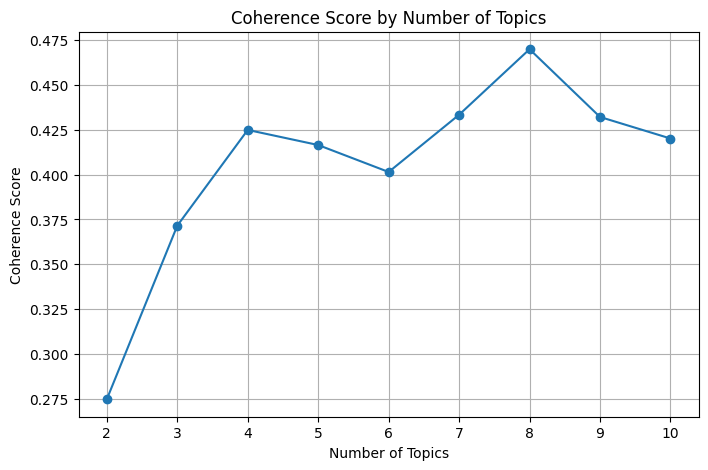

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    topic_numbers,
    coherence_values,
    marker='o'
)

plt.xticks(topic_numbers)

plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score')

plt.title('Coherence Score by Number of Topics')

plt.grid()

plt.show()

In [ ]:
best_index = np.argmax(coherence_scores)

best_num_topics = list(topic_range)[best_index]

best_score = coherence_scores[best_index]

print(f"최적 Topic 수: {best_num_topics}")
print(f"최고 Coherence Score: {best_score:.4f}")

ValueError: attempt to get argmax of an empty sequence

In [ ]:
#final_num_topics = 5
final_lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5, #토픽수 4 충분히 학습
    random_state=42,
    passes=20,
    iterations=200,
    alpha='auto',
    eta='auto'
)

In [ ]:
for idx, topic in final_lda_model.print_topics(
    num_topics=5,
    num_words=10
):

    print(f"\n{'='*60}")
    print(f"Topic {idx}")
    print(topic)


Topic 0
0.025*"에그타르트" + 0.024*"커피" + 0.016*"원두" + 0.013*"맛있다" + 0.008*"두쫀쿠" + 0.008*"라떼" + 0.008*"두바이" + 0.008*"로스팅" + 0.007*"블루리본" + 0.006*"쿠키"

Topic 1
0.009*"음식점" + 0.009*"베이글" + 0.008*"케이크" + 0.006*"예약" + 0.005*"플레" + 0.005*"식당" + 0.005*"달인" + 0.004*"꽃집" + 0.004*"길동" + 0.004*"동반"

Topic 2
0.021*"할인" + 0.006*"청소" + 0.005*"사용" + 0.005*"코드" + 0.005*"클릭" + 0.005*"엑스" + 0.004*"작업" + 0.004*"거래소" + 0.004*"토큰" + 0.004*"구매"

Topic 3
0.036*"좋다" + 0.030*"디저트" + 0.021*"분위기" + 0.020*"브런치" + 0.016*"맛있다" + 0.014*"커피" + 0.014*"감성" + 0.012*"데이트" + 0.010*"주말" + 0.010*"메뉴"

Topic 4
0.050*"베이커리" + 0.036*"빵집" + 0.023*"바게트" + 0.013*"샌드위치" + 0.009*"맛있다" + 0.008*"천호동" + 0.007*"쭈꾸미" + 0.007*"호주" + 0.007*"케이크" + 0.007*"초코"


In [ ]:
topic_results = []

for topic_id in range(5):

    words = final_lda_model.show_topic(
        topic_id,
        topn=15
    )

    word_list = [
        word
        for word, score in words
    ]

    topic_results.append({
        'Topic': topic_id + 1,
        'Keywords': ', '.join(word_list)
    })

topic_results_df = pd.DataFrame(topic_results)

topic_results_df

#0:공간
#1:분위기
#2:빵
#3:커피/음료
#4:가격

,Topic,Keywords
0,1,"샌드, 보스, 울트라, 헤드폰, 세대, 베이글, 음식점, 오픈, 컬러, 오텀, 사용..."
1,2,"좋다, 디저트, 맛있다, 분위기, 커피, 브런치, 감성, 메뉴, 데이트, 주말, 케..."
2,3,"베이커리, 빵집, 에그타르트, 바게트, 샌드위치, 본점, 잠실, 롯데, 초코, 팝업..."
3,4,"원두, 커피, 채스, 젤라또, 라떼, 로스팅, 로스, 드립, 터리, 에스프레소, 베..."
4,5,"바이, 할인, 낸스, 수수료, 가입, 코인, 링크, 머신, 거래, 비트, 콘티, 청..."


In [ ]:
topic_words_df.to_csv(
    "lda_topic_keywords.csv",
    index=False,
    encoding="utf-8-sig"
)

,cleaned_tokens_analysis,cleaned_tokens_add
0,둔촌동역 메뉴 블루리본 올림픽 공원 양재대로 둔촌동역 출구 블루리본 맛집 주차 공간...,둔촌동역 메뉴 블루리본 올림픽 공원 양재대로 둔촌동역 출구 블루리본 맛집 주차 공간...
1,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 좋다 분위기 조용하다 깔...,분위기 좋다 블루리본 디저트 솔직 아몬드 인상 디저트 메뉴 좋다 분위기 조용하다 깔...
2,올림픽 공원 골목 국민 떡볶이 건물 주차장 따로 올림픽 공원 가깝다 저희 올림픽 공...,올림픽 공원 골목 국민 떡볶이 건물 주차장 따로 올림픽 공원 가깝다 저희 올림픽 공...
3,블루리본 분위기 좋다 토일 라스트 마감 루시 우연히 발견 블루리본 메뉴 생각 다양하...,블루리본 분위기 좋다 토일 라스트 마감 루시 우연히 발견 블루리본 메뉴 생각 다양하...
4,찰나 순간 기록 솔직 이미 감성 소문 자자하다 참새 방앗간 무조건 양재대로 강동역 ...,찰나 순간 기록 솔직 이미 감성 소문 자자하다 참새 방앗간 무조건 양재대로 강동역 ...
5,인생 크림 라떼 맛있다 맛있다 크림 라떼 특별하다 여러분 인생 크림 라떼 맛집 크림...,인생 크림 라떼 맛있다 맛있다 크림 라떼 특별하다 여러분 인생 크림 라떼 맛집 크림...
6,둔촌동역 올림픽 공원 블루리본 커피 맛집 양재대로 주차 한살림 둔촌 유료 주차장 용...,둔촌동역 올림픽 공원 블루리본 커피 맛집 양재대로 주차 한살림 둔촌 유료 주차장 용...
7,크림 라떼 주차 큰길 안쪽 아지트 양재대로 둔촌동역 출구 도보 평일 주말 주차 안내...,크림 라떼 주차 큰길 안쪽 아지트 양재대로 둔촌동역 출구 도보 평일 주말 주차 안내...
8,아몬드 디저트 특별하다 라멘 식사 주차 분위기 좋다 자연 외관 감각 느낌 한글 거의...,아몬드 디저트 특별하다 라멘 식사 주차 분위기 좋다 자연 외관 감각 느낌 한글 거의...
9,둔촌 올림픽 공원 산책 달달 디저트 둔촌동역 출구 도보 올림픽공원역 출구 도보 올림...,둔촌 올림픽 공원 산책 달달 디저트 둔촌동역 출구 도보 올림픽공원역 출구 도보 올림...
